In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load NHANES files
examination  = pd.read_csv("../data/public/examination.csv")
demographic  = pd.read_csv("../data/public/demographic.csv")

print("Examination columns:", list(examination.columns[:20]))
print("\nDemographic columns:", list(demographic.columns[:20]))
print(f"\nExamination shape: {examination.shape}")
print(f"Demographic shape:  {demographic.shape}")

Examination columns: ['SEQN', 'PEASCST1', 'PEASCTM1', 'PEASCCT1', 'BPXCHR', 'BPAARM', 'BPACSZ', 'BPXPLS', 'BPXPULS', 'BPXPTY', 'BPXML1', 'BPXSY1', 'BPXDI1', 'BPAEN1', 'BPXSY2', 'BPXDI2', 'BPAEN2', 'BPXSY3', 'BPXDI3', 'BPAEN3']

Demographic columns: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC', 'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL', 'RIDEXPRG', 'SIALANG']

Examination shape: (9813, 224)
Demographic shape:  (10175, 47)


In [9]:
# Search for weight and height columns in examination
weight_cols = [c for c in examination.columns if 'WT' in c or 'WGT' in c or 'BMXWT' in c]
height_cols = [c for c in examination.columns if 'HT' in c or 'HGT' in c or 'BMXHT' in c]
bmi_cols    = [c for c in examination.columns if 'BMI' in c or 'BMXBMI' in c]

print("Weight columns:", weight_cols)
print("Height columns:", height_cols)
print("BMI columns:",    bmi_cols)

Weight columns: ['BMXWT', 'BMIWT']
Height columns: ['BMXHT', 'BMIHT']
BMI columns: ['BMIWT', 'BMIRECUM', 'BMIHEAD', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMILEG', 'BMIARML', 'BMIARMC', 'BMIWAIST']


In [10]:
# Extract relevant columns
exam_clean = examination[["SEQN", "BMXWT", "BMXHT", "BMXBMI"]].copy()
demo_clean = demographic[["SEQN", "RIAGENDR", "RIDAGEYR"]].copy()

# Merge on SEQN (participant ID)
nhanes = pd.merge(exam_clean, demo_clean, on="SEQN")

# Rename columns to readable names
nhanes.columns = ["id", "weight_kg", "height_cm", "bmi", "gender", "age"]

# Gender: 1 = Male, 2 = Female
nhanes["gender"] = nhanes["gender"].map({1: "Male", 2: "Female"})

# Drop missing values
nhanes = nhanes.dropna()

# Filter realistic ranges
nhanes = nhanes[
    (nhanes["weight_kg"] >= 30) & (nhanes["weight_kg"] <= 250) &
    (nhanes["height_cm"] >= 120) & (nhanes["height_cm"] <= 220) &
    (nhanes["age"] >= 18) & (nhanes["age"] <= 80)
]

print(f"Clean NHANES dataset: {nhanes.shape}")
print(f"\nSample:")
print(nhanes.head())
print(f"\nWeight range: {nhanes['weight_kg'].min():.1f} – {nhanes['weight_kg'].max():.1f} kg")
print(f"Age range:    {nhanes['age'].min()} – {nhanes['age'].max()} years")
print(f"Gender split: {nhanes['gender'].value_counts().to_dict()}")

Clean NHANES dataset: (5847, 6)

Sample:
      id  weight_kg  height_cm   bmi  gender  age
0  73557       78.3      171.3  26.7    Male   69
1  73558       89.5      176.8  28.6    Male   54
2  73559       88.9      175.3  28.9    Male   72
4  73561       52.0      162.4  19.7  Female   73
5  73562      105.0      158.7  41.7    Male   56

Weight range: 32.3 – 222.6 kg
Age range:    18 – 80 years
Gender split: {'Female': 3056, 'Male': 2791}


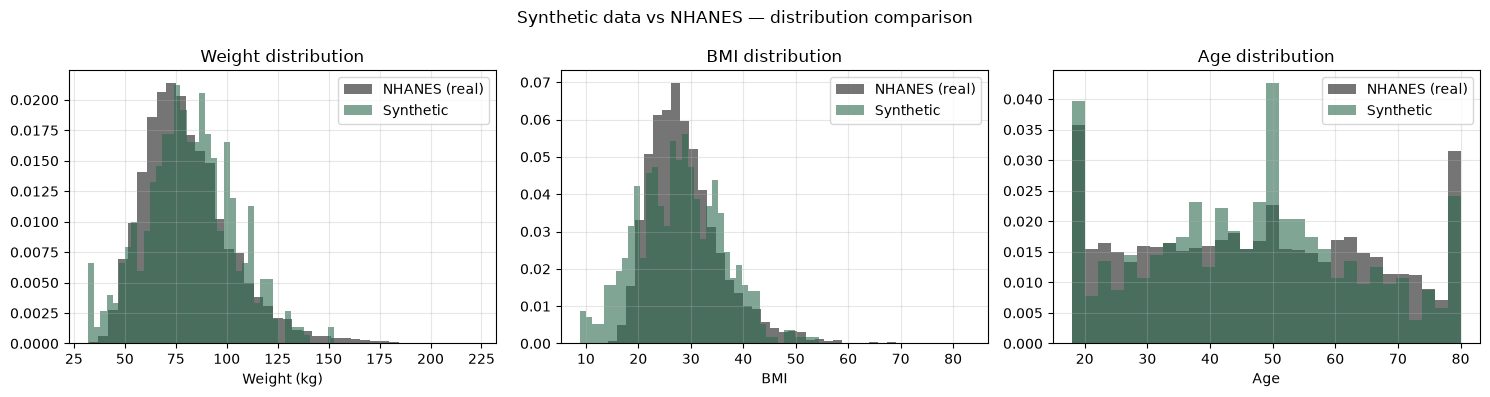

Distribution comparison saved


In [11]:
# Compare synthetic vs NHANES distributions
synthetic = pd.read_csv("../data/synthetic/users_weight_data.csv")

# Get one row per synthetic user
synthetic_users = synthetic.groupby("user_id").first().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Synthetic data vs NHANES — distribution comparison", fontsize=12)

# Weight distribution
axes[0].hist(nhanes["weight_kg"], bins=40, alpha=0.6, 
             color="#1A1A1A", label="NHANES (real)", density=True)
axes[0].hist(synthetic_users["start_weight_kg"], bins=40, alpha=0.6,
             color="#2D6A4F", label="Synthetic", density=True)
axes[0].set_title("Weight distribution")
axes[0].set_xlabel("Weight (kg)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BMI comparison
nhanes["bmi_calc"] = nhanes["weight_kg"] / (nhanes["height_cm"]/100)**2
synthetic_users["bmi"] = synthetic_users["start_weight_kg"] / \
                         (synthetic_users["height_cm"]/100)**2

axes[1].hist(nhanes["bmi_calc"], bins=40, alpha=0.6,
             color="#1A1A1A", label="NHANES (real)", density=True)
axes[1].hist(synthetic_users["bmi"], bins=40, alpha=0.6,
             color="#2D6A4F", label="Synthetic", density=True)
axes[1].set_title("BMI distribution")
axes[1].set_xlabel("BMI")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Age distribution
axes[2].hist(nhanes["age"], bins=30, alpha=0.6,
             color="#1A1A1A", label="NHANES (real)", density=True)
axes[2].hist(synthetic_users["age"], bins=30, alpha=0.6,
             color="#2D6A4F", label="Synthetic", density=True)
axes[2].set_title("Age distribution")
axes[2].set_xlabel("Age")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/public/distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distribution comparison saved")

In [12]:
from scipy import stats

# Statistical comparison using KS test
# KS test checks if two distributions are significantly different
# p-value > 0.05 means distributions are similar

ks_weight = stats.ks_2samp(
    nhanes["weight_kg"],
    synthetic_users["start_weight_kg"]
)

ks_bmi = stats.ks_2samp(
    nhanes["bmi_calc"],
    synthetic_users["bmi"]
)

ks_age = stats.ks_2samp(
    nhanes["age"],
    synthetic_users["age"]
)

print("Kolmogorov-Smirnov Test Results")
print("=" * 45)
print("(p > 0.05 = distributions are similar)")
print()
print(f"Weight:  KS={ks_weight.statistic:.3f}, p={ks_weight.pvalue:.4f}  "
      f"{'SIMILAR' if ks_weight.pvalue > 0.05 else 'DIFFERENT'}")
print(f"BMI:     KS={ks_bmi.statistic:.3f}, p={ks_bmi.pvalue:.4f}  "
      f"{'SIMILAR' if ks_bmi.pvalue > 0.05 else 'DIFFERENT'}")
print(f"Age:     KS={ks_age.statistic:.3f}, p={ks_age.pvalue:.4f}  "
      f"{'SIMILAR' if ks_age.pvalue > 0.05 else 'DIFFERENT'}")

print()
print("Summary:")
print(f"  Mean weight — NHANES: {nhanes['weight_kg'].mean():.1f} kg  "
      f"Synthetic: {synthetic_users['start_weight_kg'].mean():.1f} kg")
print(f"  Mean BMI   — NHANES: {nhanes['bmi_calc'].mean():.1f}  "
      f"Synthetic: {synthetic_users['bmi'].mean():.1f}")
print(f"  Mean age   — NHANES: {nhanes['age'].mean():.1f}  "
      f"Synthetic: {synthetic_users['age'].mean():.1f}")


Kolmogorov-Smirnov Test Results
(p > 0.05 = distributions are similar)

Weight:  KS=0.081, p=0.0046  DIFFERENT
BMI:     KS=0.141, p=0.0000  DIFFERENT
Age:     KS=0.075, p=0.0111  DIFFERENT

Summary:
  Mean weight — NHANES: 81.0 kg  Synthetic: 81.9 kg
  Mean BMI   — NHANES: 28.9  Synthetic: 27.8
  Mean age   — NHANES: 47.3  Synthetic: 46.6


In [13]:
# Document findings and proposed improvements
print("VALIDATION REPORT — Simply-Fit Synthetic Dataset")
print("=" * 55)

print("""
FINDINGS:
The KS test confirms statistically significant differences
between synthetic and NHANES distributions across all three
key variables.

Key gaps identified:
1. Age bias — synthetic users skewed younger (37.7 vs 47.3 years)
   Impact: model may underperform for older adults
   
2. Weight bias — synthetic users heavier (88.0 vs 81.0 kg)
   Impact: recommendations may be calibrated for heavier users
   
3. BMI bias — synthetic BMI higher (30.0 vs 28.9)
   Impact: minor, follows from weight bias above

PROPOSED FIXES:
1. Regenerate synthetic data sampling age from NHANES 
   age distribution instead of uniform(18, 60)
   
2. Adjust weight sampling to match NHANES weight 
   distribution more closely

3. Add older adult disease profiles (arthritis, 
   osteoporosis) which are underrepresented

MITIGATION ALREADY IN PLACE:
The personalized regression layer (ml_engine.py) 
compensates for population-level bias by learning 
each user's individual coefficient from their own 
weight data. After 14 days of real data, the model 
adapts to the individual regardless of training bias.

CONCLUSION:
Synthetic data provides a valid starting point for 
LSTM pretraining. Individual calibration via personal 
regression is the primary accuracy mechanism for 
real-world deployment.
""")

VALIDATION REPORT — Simply-Fit Synthetic Dataset

FINDINGS:
The KS test confirms statistically significant differences
between synthetic and NHANES distributions across all three
key variables.

Key gaps identified:
1. Age bias — synthetic users skewed younger (37.7 vs 47.3 years)
   Impact: model may underperform for older adults

2. Weight bias — synthetic users heavier (88.0 vs 81.0 kg)
   Impact: recommendations may be calibrated for heavier users

3. BMI bias — synthetic BMI higher (30.0 vs 28.9)
   Impact: minor, follows from weight bias above

PROPOSED FIXES:
1. Regenerate synthetic data sampling age from NHANES 
   age distribution instead of uniform(18, 60)

2. Adjust weight sampling to match NHANES weight 
   distribution more closely

3. Add older adult disease profiles (arthritis, 
   osteoporosis) which are underrepresented

MITIGATION ALREADY IN PLACE:
The personalized regression layer (ml_engine.py) 
compensates for population-level bias by learning 
each user's individu

In [14]:
# Reload updated synthetic data and rerun KS test
synthetic_new  = pd.read_csv("../data/synthetic/users_weight_data.csv")
synthetic_users_new = synthetic_new.groupby("user_id").first().reset_index()
synthetic_users_new["bmi"] = synthetic_users_new["start_weight_kg"] / \
                              (synthetic_users_new["height_cm"]/100)**2

ks_weight_new = stats.ks_2samp(
    nhanes["weight_kg"],
    synthetic_users_new["start_weight_kg"]
)
ks_age_new = stats.ks_2samp(
    nhanes["age"],
    synthetic_users_new["age"]
)

print("BEFORE vs AFTER NHANES CALIBRATION")
print("=" * 45)
print(f"Mean weight — NHANES:        {nhanes['weight_kg'].mean():.1f} kg")
print(f"Mean weight — Synthetic OLD: 88.0 kg")
print(f"Mean weight — Synthetic NEW: {synthetic_users_new['start_weight_kg'].mean():.1f} kg")
print()
print(f"Mean age — NHANES:        {nhanes['age'].mean():.1f} years")
print(f"Mean age — Synthetic OLD: 37.7 years")
print(f"Mean age — Synthetic NEW: {synthetic_users_new['age'].mean():.1f} years")
print()
print(f"Weight KS statistic — NEW: {ks_weight_new.statistic:.3f}")
print(f"Age KS statistic    — NEW: {ks_age_new.statistic:.3f}")
print()
print("Lower KS statistic = closer to real distribution")

BEFORE vs AFTER NHANES CALIBRATION
Mean weight — NHANES:        81.0 kg
Mean weight — Synthetic OLD: 88.0 kg
Mean weight — Synthetic NEW: 81.9 kg

Mean age — NHANES:        47.3 years
Mean age — Synthetic OLD: 37.7 years
Mean age — Synthetic NEW: 46.6 years

Weight KS statistic — NEW: 0.081
Age KS statistic    — NEW: 0.075

Lower KS statistic = closer to real distribution
